In [83]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree

In [84]:
df = pd.read_csv("house_prices.csv")
df.sample(5)

,House,Size (sq ft),Bedrooms,Age (years),Price ($1000s)
159,160,1630,2,37,164.1
168,169,1560,3,13,201.7
85,86,1895,2,5,248.9
67,68,1730,2,20,204.6
173,174,2018,4,16,267.2


In [85]:
X= df.iloc[:, 1:4]
y= df.iloc[:,-1]

# Train test split

In [86]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

# Model Selection

In [87]:
model= RandomForestRegressor(n_estimators=100, random_state=42, max_depth=3)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [88]:
y_pred= model.predict(X_test)

In [89]:
result= pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})
print(result)

     Actual Price  Predicted Price
30          177.0       169.713531
172         167.7       189.391956
84          221.0       196.369466
199         195.9       241.520640
60          221.8       192.713145
155         104.3       135.582527
45          138.8       175.604151
182         193.8       196.694688
9           160.0       153.351496
196         382.1       377.791922
136         225.7       245.304890
187         289.7       301.897222
207         256.9       219.654184
126         208.3       190.478179
15          138.5       170.840371
73           80.8       103.107423
165         215.9       206.285983
18          306.8       253.478492
168         201.7       189.805419
93          324.6       327.487926
75          193.1       202.635114
55          234.2       257.853201
147         179.9       135.929615
109          83.1       100.809645
108         222.1       242.554060
142         159.0       168.335790
25          245.5       244.945204
125         268.5   

# Regression Metrics

In [90]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 19.437223973125924
R2 Score: 0.8933932660560153


# Predict new house price

In [91]:
new_house= [[2000, 3, 3]]
prediction= model.predict(new_house)
print("Predicted Price:", prediction)

Predicted Price: [264.61890949]


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


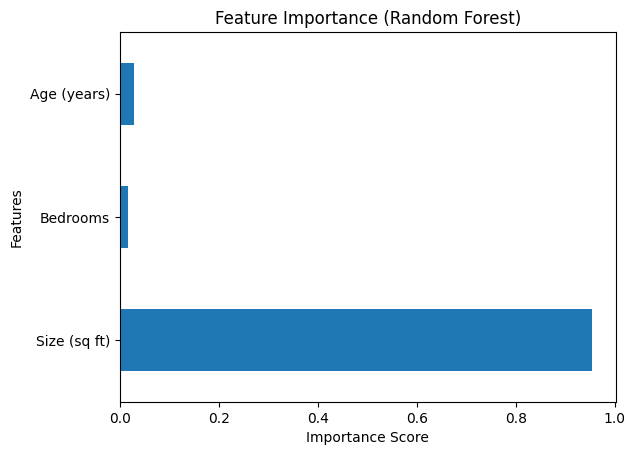

In [92]:
importance = model.feature_importances_
# print(importance) This prints importance in arrat
feat_importance = pd.Series(importance, index=X.columns)
feat_importance.plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

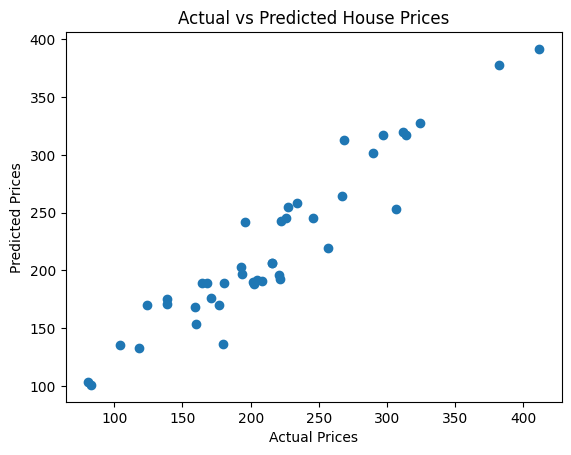

In [93]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Decsion Tree (Any 1 out of 100)

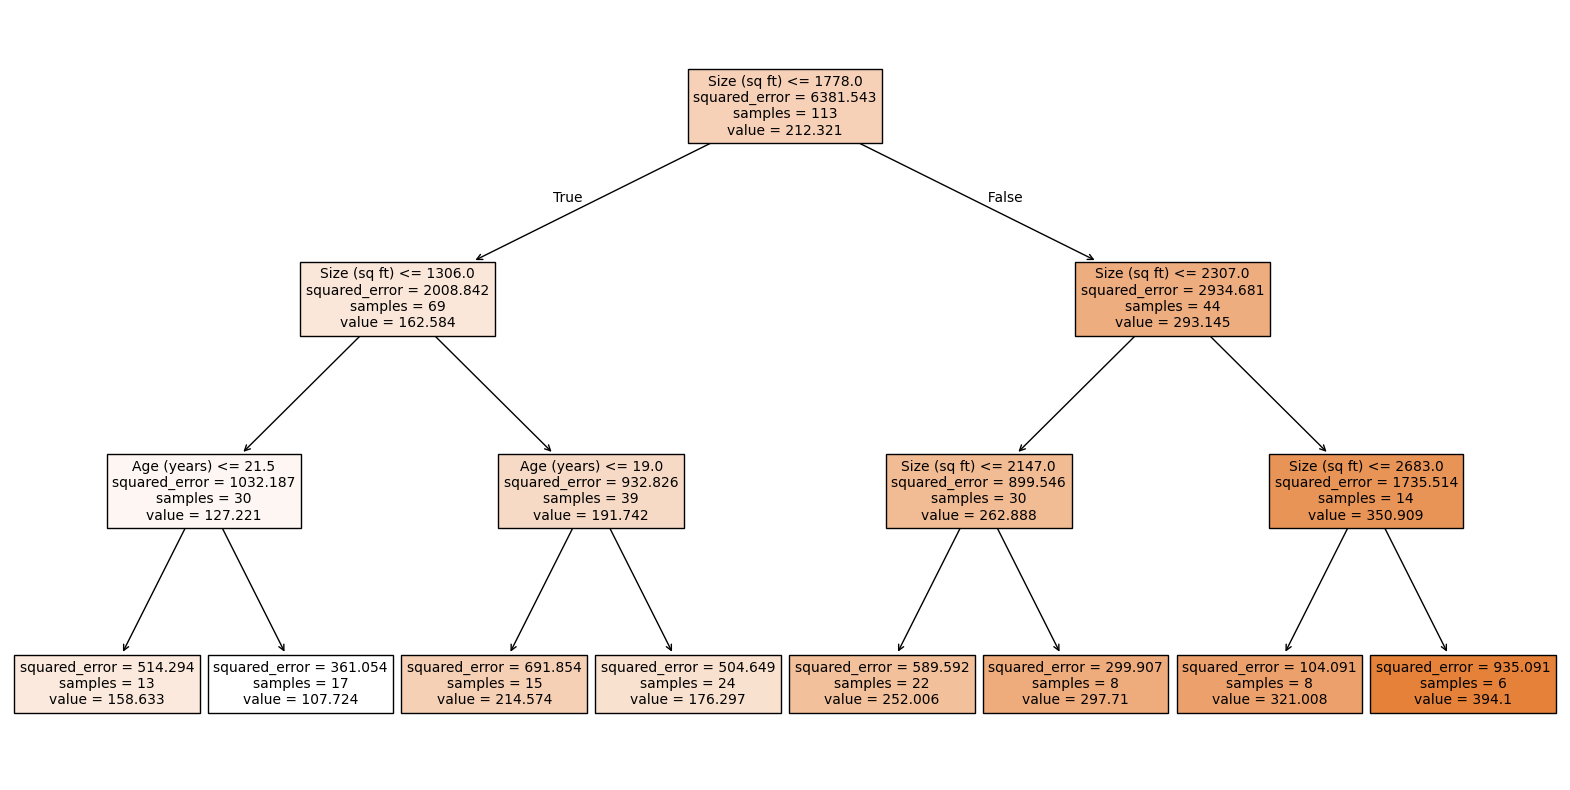

In [94]:
plt.figure(figsize=(20,10))
tree = model.estimators_[0]
plot_tree(tree, feature_names= X.columns, filled= True, fontsize=10)
plt.show()